<a href="https://colab.research.google.com/github/mks999/-FlaskLive/blob/main/TSA_Assignment3_MAnish_Sharma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
!pip install pandas scikit-learn matplotlib seaborn openpyxl
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from IPython.display import display

In [14]:
# Load the dataset
data = pd.read_excel('AirQualityUCI.xlsx')

# Replace -200 with NaN
data = data.replace(-200, np.nan) # Change to np.nan for numerical representation

# Interpolate missing values
# Convert 'Date' and 'Time' to datetime objects before interpolation
data['Datetime'] = pd.to_datetime(data['Date'].astype(str) + ' ' + data['Time'].astype(str))
# Remove 'Date' and 'Time' columns from numerical features
numerical_features = data.select_dtypes(include=['number']).columns.difference(['Date', 'Time'])
data[numerical_features] = data[numerical_features].interpolate(method='linear')

# Select only numerical features for scaling
#data_scaled = data[numerical_features].copy()  # Create a copy for scaling

# Scale data using MinMaxScaler
scaler = MinMaxScaler()
data[numerical_features] = scaler.fit_transform(data[numerical_features]) # Scale directly on original data

Data Shape: (9357, 16)

Summary Statistics:


,Date,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Datetime
count,9357,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357
mean,2004-09-21 04:30:05.193972480,0.172085,0.327241,0.222364,0.157720,0.305213,0.162430,0.216302,0.318685,0.405653,0.352524,0.432941,0.503006,0.408014,2004-09-21 16:00:00
min,2004-03-10 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2004-03-10 18:00:00
25%,2004-06-16 00:00:00,0.084746,0.208438,0.226734,0.068060,0.192681,0.063643,0.140633,0.219129,0.303957,0.222548,0.293011,0.334695,0.267598,2004-06-16 05:00:00
50%,2004-09-21 00:00:00,0.144068,0.301257,0.226734,0.128003,0.287906,0.120515,0.203961,0.304494,0.408498,0.325405,0.418817,0.508799,0.393297,2004-09-21 16:00:00
75%,2004-12-28 00:00:00,0.237288,0.424776,0.226734,0.219325,0.401884,0.219364,0.273430,0.397986,0.502361,0.465733,0.562903,0.667190,0.548288,2004-12-28 03:00:00
max,2005-04-04 00:00:00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2005-04-04 14:00:00
std,NaN,0.121334,0.156698,0.062819,0.117990,0.146314,0.138326,0.108317,0.137553,0.154317,0.175711,0.188868,0.216142,0.196546,NaN



Data Types:
Date             datetime64[ns]
Time                     object
CO(GT)                  float64
PT08.S1(CO)             float64
NMHC(GT)                float64
C6H6(GT)                float64
PT08.S2(NMHC)           float64
NOx(GT)                 float64
PT08.S3(NOx)            float64
NO2(GT)                 float64
PT08.S4(NO2)            float64
PT08.S5(O3)             float64
T                       float64
RH                      float64
AH                      float64
Datetime         datetime64[ns]
dtype: object

Missing Values:
Date             0.0
Time             0.0
CO(GT)           0.0
PT08.S1(CO)      0.0
NMHC(GT)         0.0
C6H6(GT)         0.0
PT08.S2(NMHC)    0.0
NOx(GT)          0.0
PT08.S3(NOx)     0.0
NO2(GT)          0.0
PT08.S4(NO2)     0.0
PT08.S5(O3)      0.0
T                0.0
RH               0.0
AH               0.0
Datetime         0.0
dtype: float64


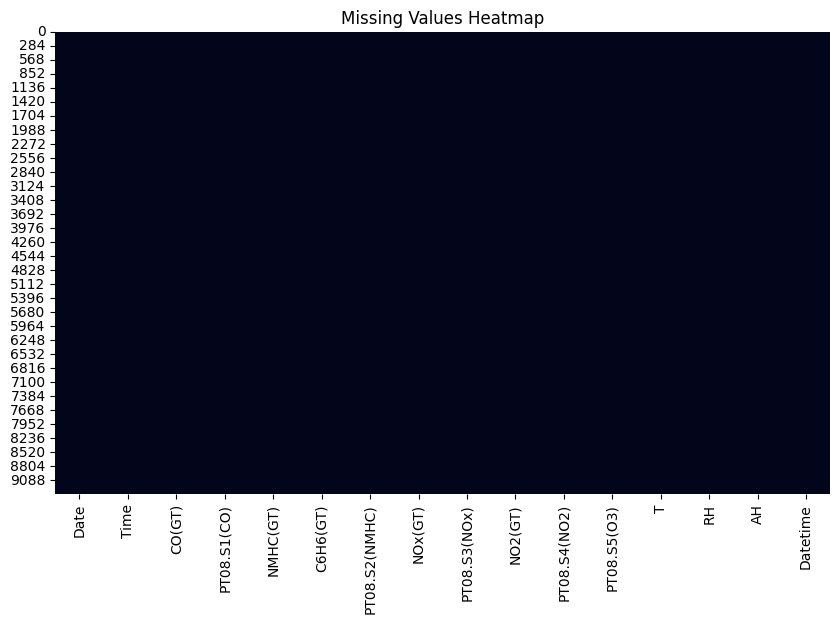

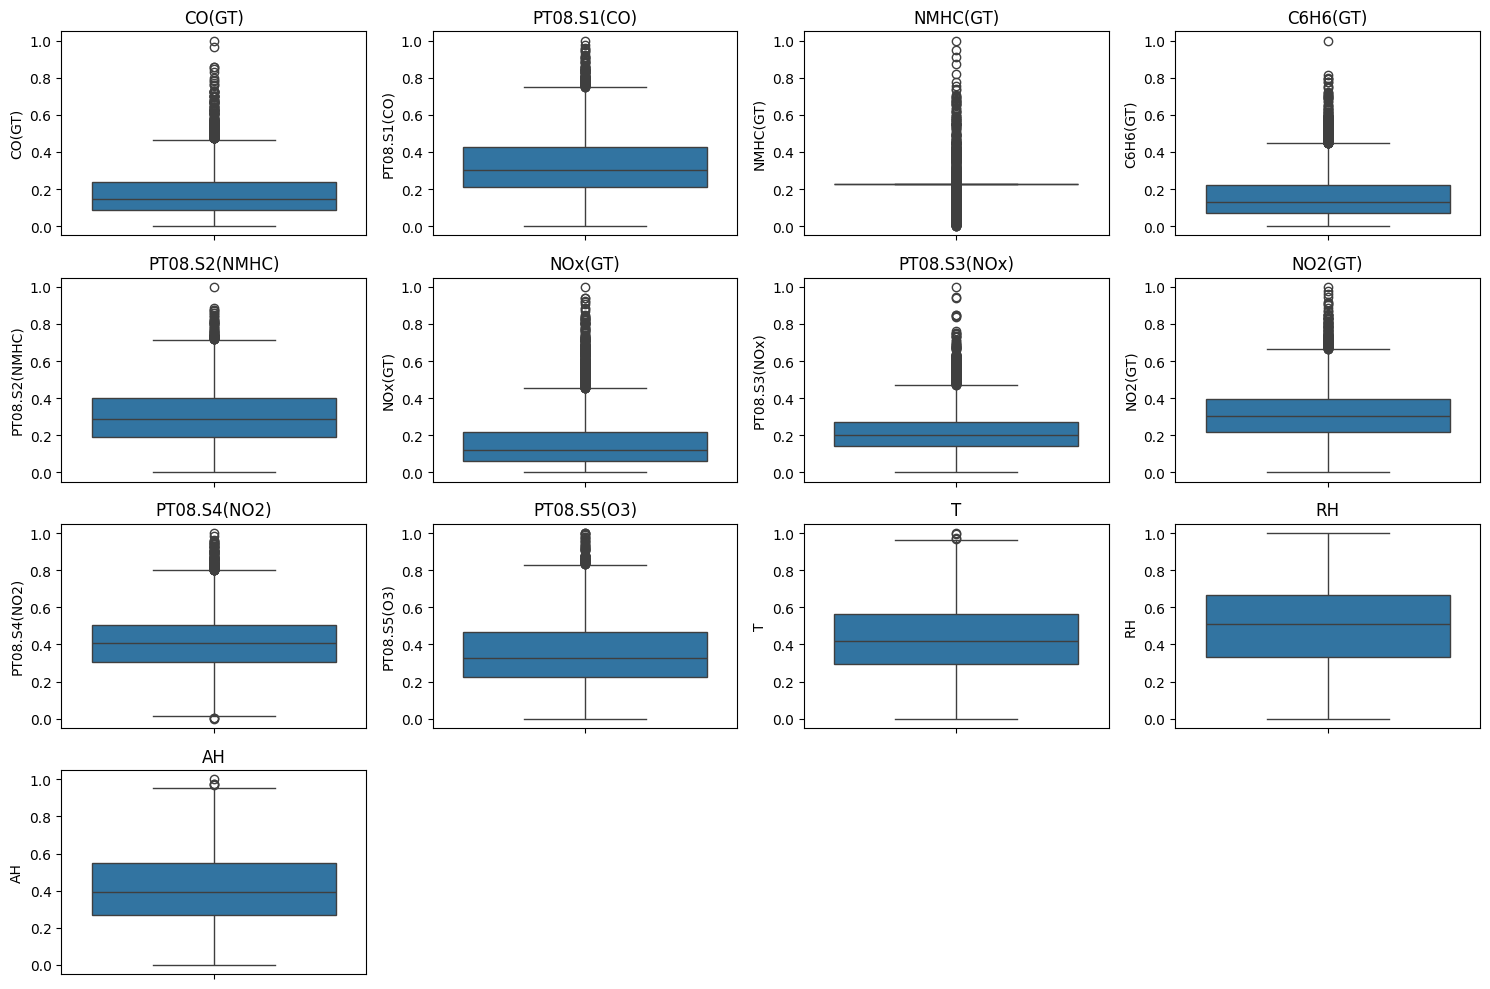

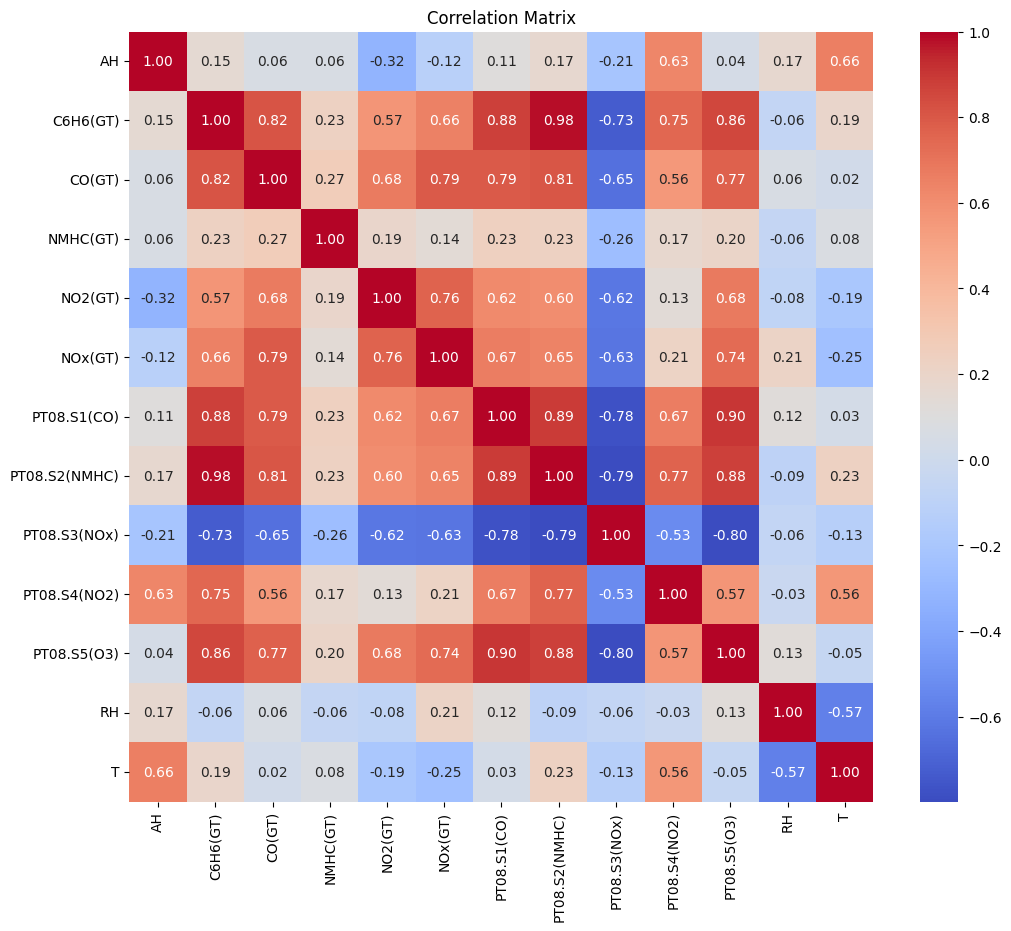

In [15]:
# Data Shape and Summary Statistics
print("Data Shape:", data.shape)
print("\nSummary Statistics:")
display(data.describe())

# Data Types
print("\nData Types:")
print(data.dtypes)

# Missing Values
print("\nMissing Values:")
missing_values = data.isnull().sum()
missing_percentage = (missing_values / len(data)) * 100
print(missing_percentage)

plt.figure(figsize=(10, 6))
sns.heatmap(data.isnull(), cbar=False)
plt.title('Missing Values Heatmap')
plt.show()

# Outlier Detection (using box plots for numerical features)
numerical_features_for_boxplot = data.select_dtypes(include=['float64', 'int64']).columns  # Use original data for boxplots
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_features_for_boxplot):
    plt.subplot(4, 4, i + 1)
    sns.boxplot(y=data[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# Correlation Analysis
correlation_matrix = data[numerical_features].corr()  # Use numerical features for correlation
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

# ... (rest of your EDA code - histograms, temporal trends, unique values) ...

In [17]:
# Define features (X) and target (y)
X = data[['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)',
          'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']]
y = data[['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)',
          'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']]

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, shuffle=False)

In [18]:
# Train models
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [19]:
# Make predictions
linear_predictions = linear_model.predict(X_test)
rf_predictions = rf_model.predict(X_test)

# Calculate RMSE for each target variable
rmse_linear = np.sqrt(mean_squared_error(y_test, linear_predictions, axis=0))
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_predictions, axis=0))

# Print RMSE values
print("Linear Regression RMSE:", rmse_linear)
print("Random Forest RMSE:", rmse_rf)

TypeError: got an unexpected keyword argument 'axis'

In [26]:
# Calculate RMSE for each target variable
# rmse_linear = np.sqrt(mean_squared_error(y_test, linear_predictions, axis=0))  # axis argument is not supported in this version
rmse_linear = np.sqrt(np.mean((y_test - linear_predictions)**2, axis=0)) # calculate manually
# rmse_rf = np.sqrt(mean_squared_error(y_test, rf_predictions, axis=0)) # axis argument is not supported in this version
rmse_rf = np.sqrt(np.mean((y_test - rf_predictions)**2, axis=0)) # calculate manually

# Print RMSE values
print("Linear Regression RMSE:", rmse_linear)
print("Random Forest RMSE:", rmse_rf)

Linear Regression RMSE: CO(GT)           7.924504e-17
PT08.S1(CO)      8.983677e-17
NMHC(GT)         8.089528e-17
C6H6(GT)         1.726809e-16
PT08.S2(NMHC)    7.496611e-17
NOx(GT)          2.970777e-16
PT08.S3(NOx)     1.017018e-16
NO2(GT)          2.892810e-16
PT08.S4(NO2)     2.400412e-16
PT08.S5(O3)      7.279236e-17
T                2.589829e-16
RH               2.097284e-16
AH               2.288149e-16
dtype: float64
Random Forest RMSE: CO(GT)           0.038169
PT08.S1(CO)      0.044516
NMHC(GT)         0.005140
C6H6(GT)         0.018334
PT08.S2(NMHC)    0.024892
NOx(GT)          0.035391
PT08.S3(NOx)     0.052425
NO2(GT)          0.060684
PT08.S4(NO2)     0.044197
PT08.S5(O3)      0.045251
T                0.037934
RH               0.039940
AH               0.033759
dtype: float64


In [20]:
# Calculate RMSE for each target variable
# rmse_linear = np.sqrt(mean_squared_error(y_test, linear_predictions, axis=0))  # axis argument is not supported in this version
rmse_linear = np.sqrt(np.mean((y_test - linear_predictions)**2, axis=0)) # calculate manually
# rmse_rf = np.sqrt(mean_squared_error(y_test, rf_predictions, axis=0)) # axis argument is not supported in this version
rmse_rf = np.sqrt(np.mean((y_test - rf_predictions)**2, axis=0)) # calculate manually

# Print RMSE values
print("Linear Regression RMSE:", rmse_linear)
print("Random Forest RMSE:", rmse_rf)

Linear Regression RMSE: CO(GT)           7.924504e-17
PT08.S1(CO)      8.983677e-17
NMHC(GT)         8.089528e-17
C6H6(GT)         1.726809e-16
PT08.S2(NMHC)    7.496611e-17
NOx(GT)          2.970777e-16
PT08.S3(NOx)     1.017018e-16
NO2(GT)          2.892810e-16
PT08.S4(NO2)     2.400412e-16
PT08.S5(O3)      7.279236e-17
T                2.589829e-16
RH               2.097284e-16
AH               2.288149e-16
dtype: float64
Random Forest RMSE: CO(GT)           0.038169
PT08.S1(CO)      0.044516
NMHC(GT)         0.005140
C6H6(GT)         0.018334
PT08.S2(NMHC)    0.024892
NOx(GT)          0.035391
PT08.S3(NOx)     0.052425
NO2(GT)          0.060684
PT08.S4(NO2)     0.044197
PT08.S5(O3)      0.045251
T                0.037934
RH               0.039940
AH               0.033759
dtype: float64


In [27]:
# We now Generate future predictions (using Random Forest model)
# We want to predict for the next 48 hours
future_dates = pd.date_range(start=data['Datetime'].iloc[-1] + pd.Timedelta(hours=1), periods=48, freq='H')
# Here, I will use the last 48 hours of data as input for prediction
future_features = X.tail(48)

future_predictions = rf_model.predict(future_features)
future_predictions = pd.DataFrame(future_predictions, columns=y.columns, index=future_dates)

# Create a submission DataFrame
submission_df = pd.DataFrame({
    'Date': future_predictions.index.date,
    'Time': future_predictions.index.strftime('%H:%M:%S'),
    'CO(GT)': future_predictions['CO(GT)'],
    'PT08.S1(CO)': future_predictions['PT08.S1(CO)'],
    'NMHC(GT)': future_predictions['NMHC(GT)'],
    'C6H6(GT)': future_predictions['C6H6(GT)'],
    'PT08.S2(NMHC)': future_predictions['PT08.S2(NMHC)'],
    'NOx(GT)': future_predictions['NOx(GT)'],
    'PT08.S3(NOx)': future_predictions['PT08.S3(NOx)'],
    'NO2(GT)': future_predictions['NO2(GT)'],
    'PT08.S4(NO2)': future_predictions['PT08.S4(NO2)'],
    'PT08.S5(O3)': future_predictions['PT08.S5(O3)'],
    'T': future_predictions['T'],
    'RH': future_predictions['RH'],
    'AH': future_predictions['AH']
})

# Save the submission DataFrame to an Excel file
submission_df.to_excel('submission.xlsx', index=False)

<ipython-input-27-3ac004c56b72>:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  future_dates = pd.date_range(start=data['Datetime'].iloc[-1] + pd.Timedelta(hours=1), periods=48, freq='H')


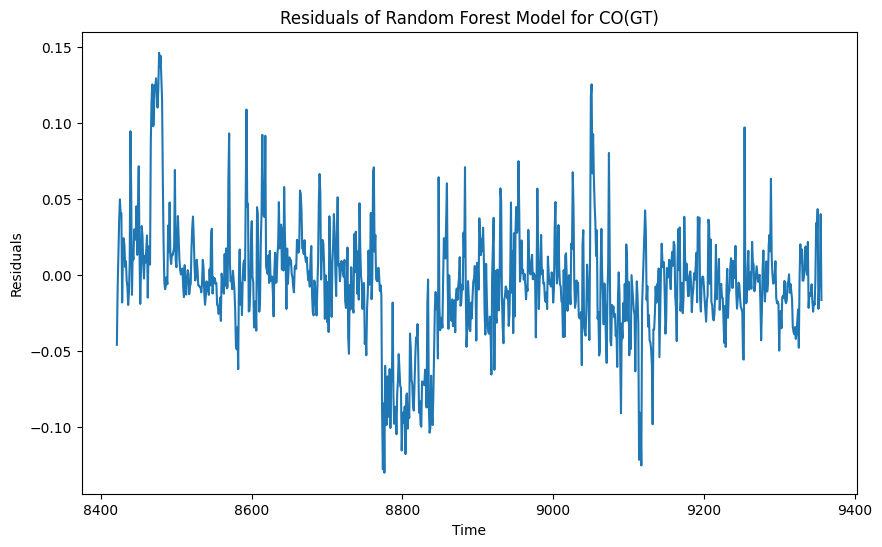

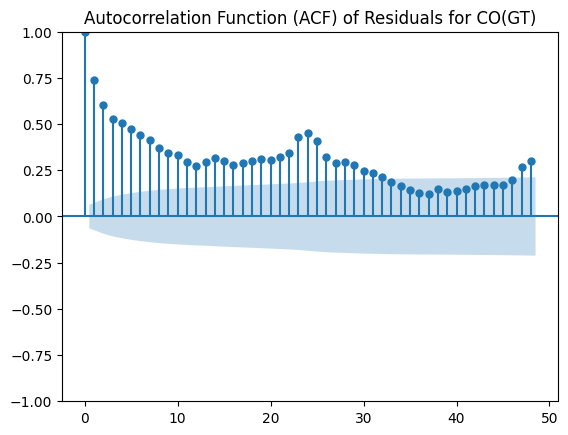

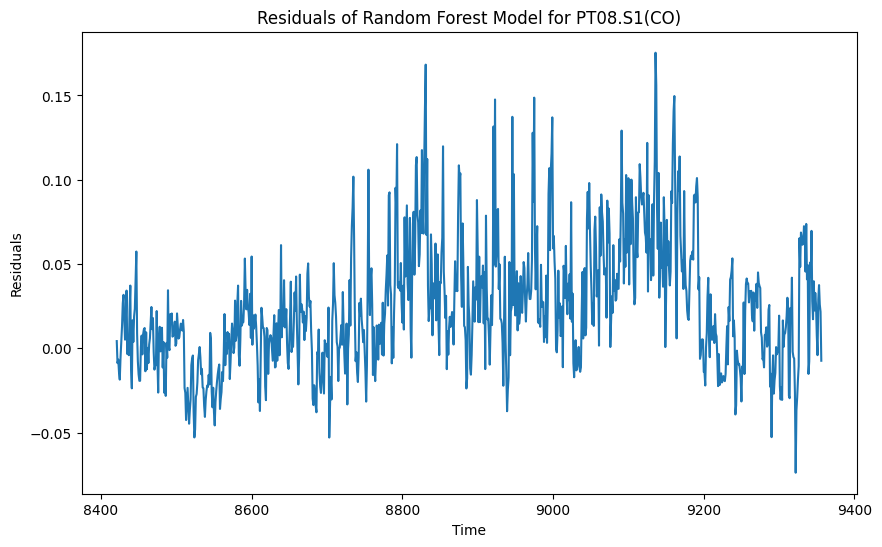

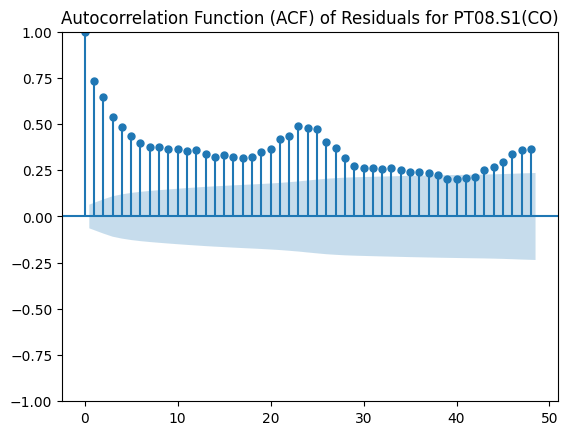

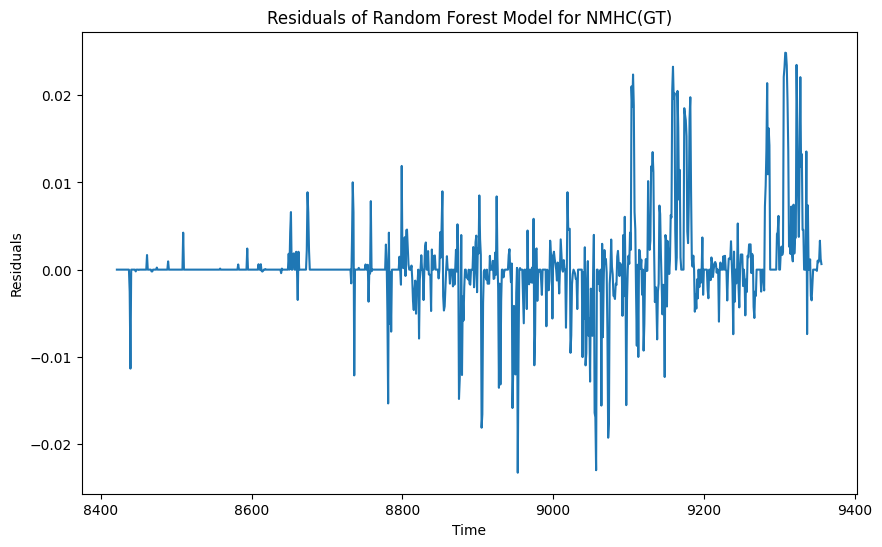

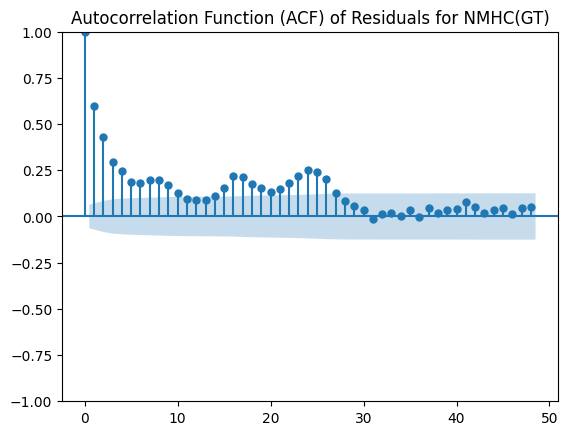

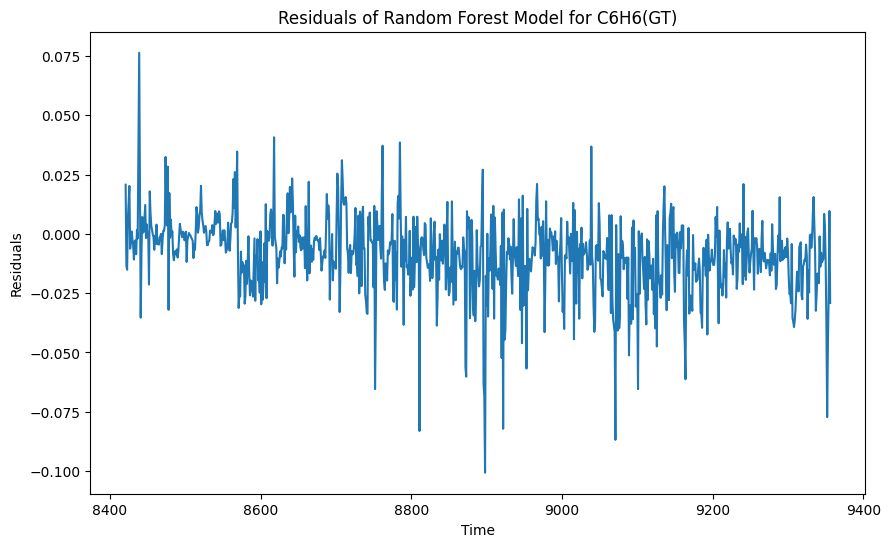

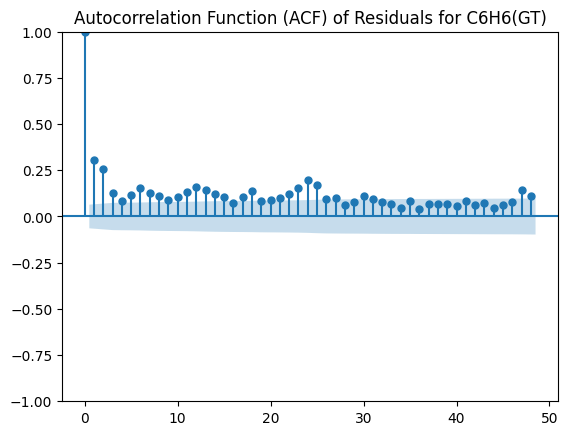

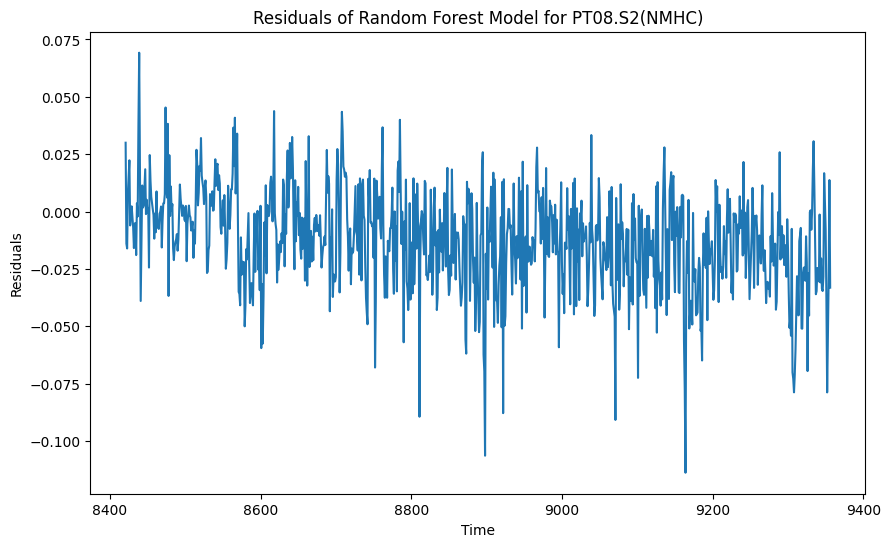

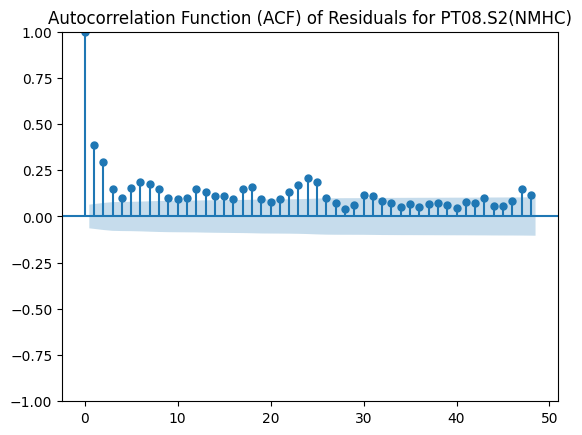

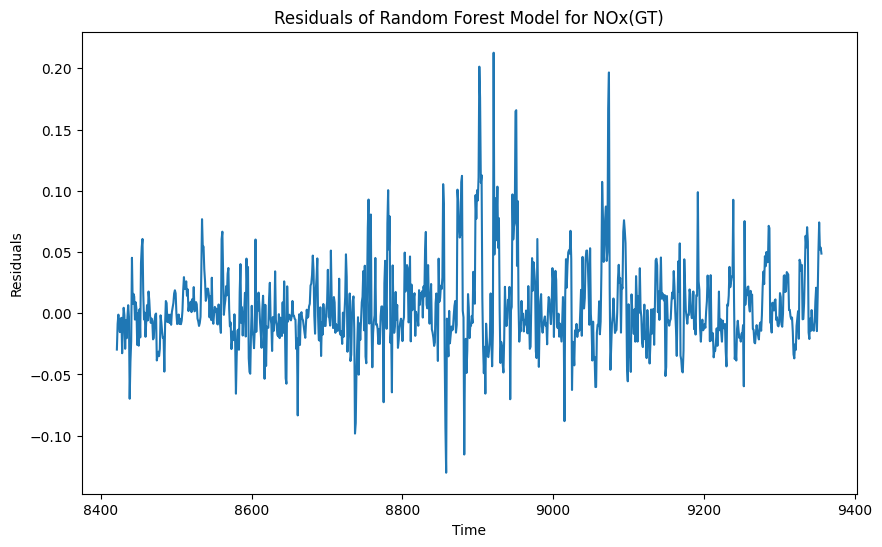

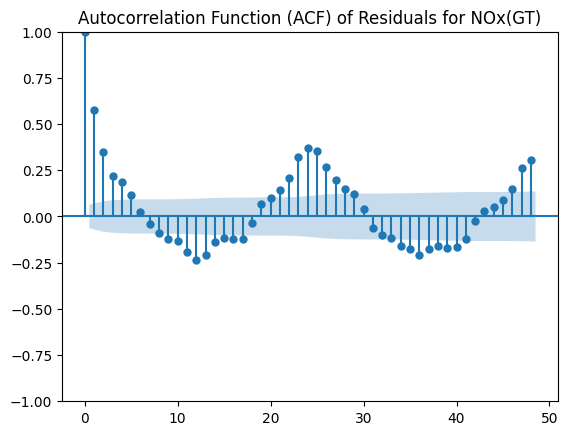

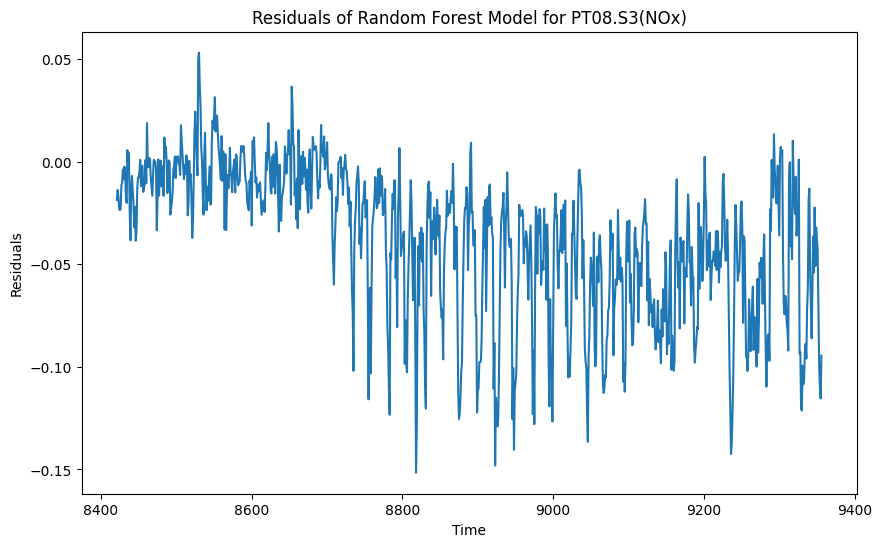

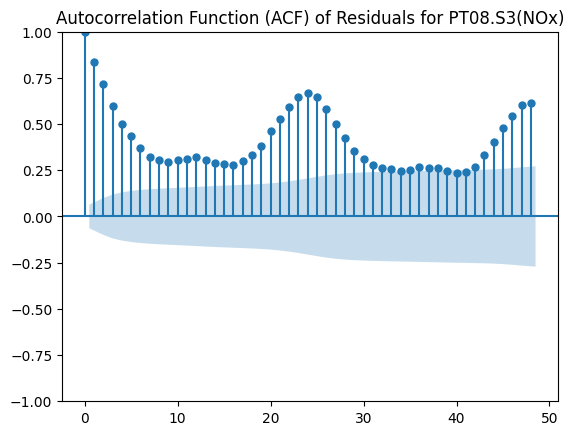

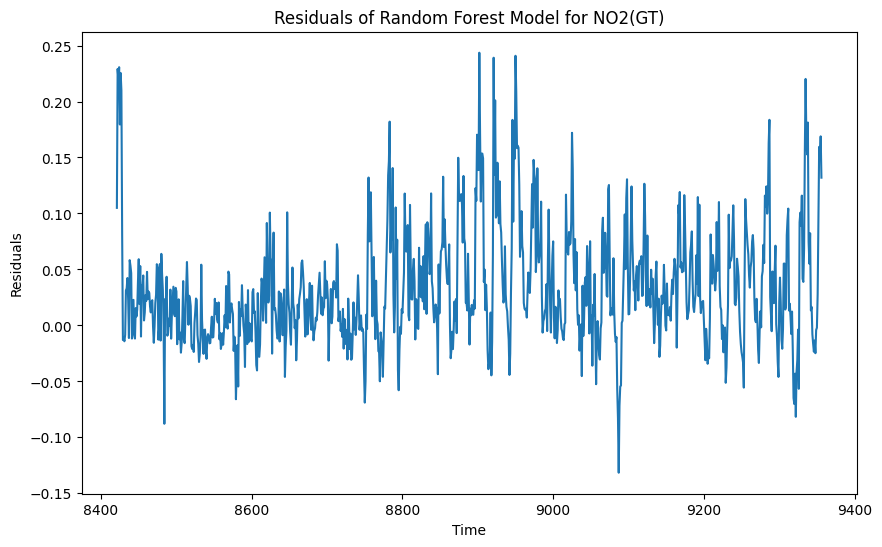

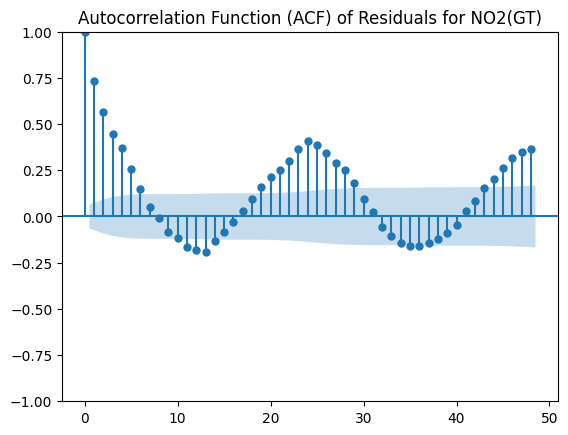

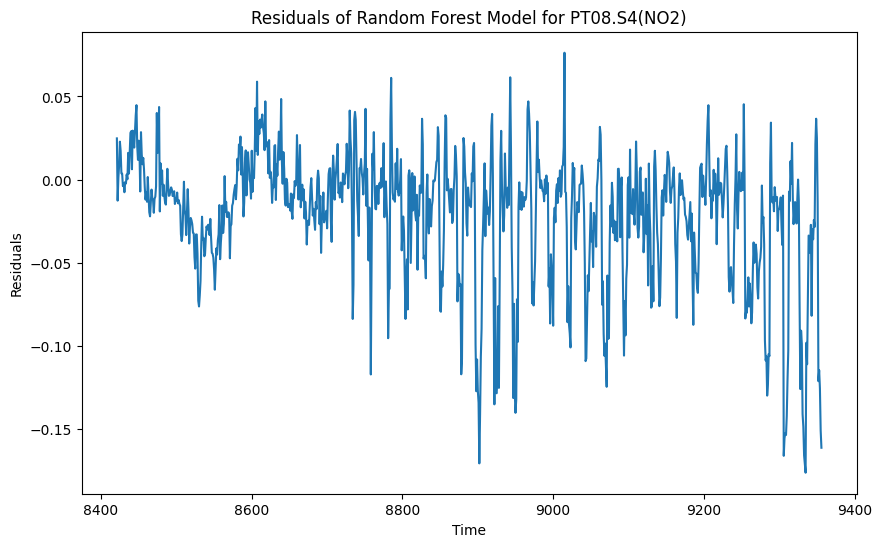

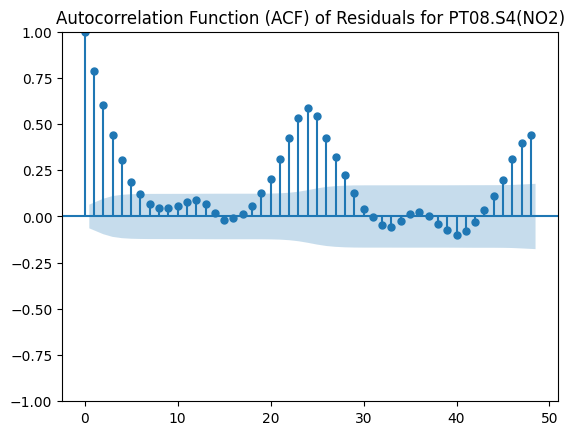

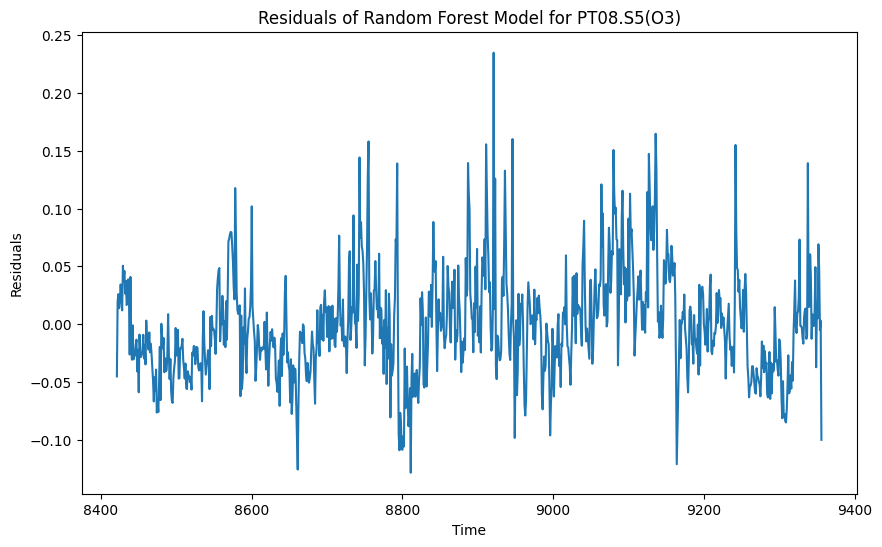

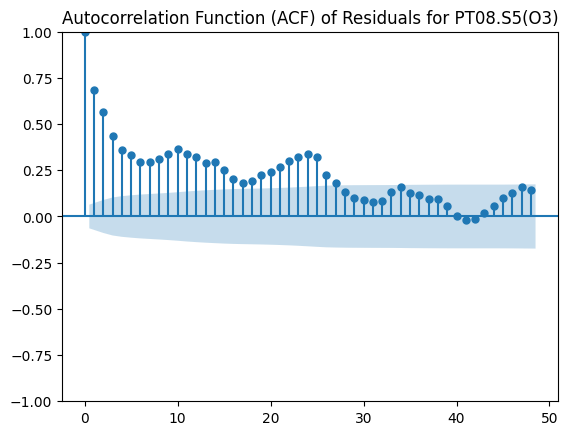

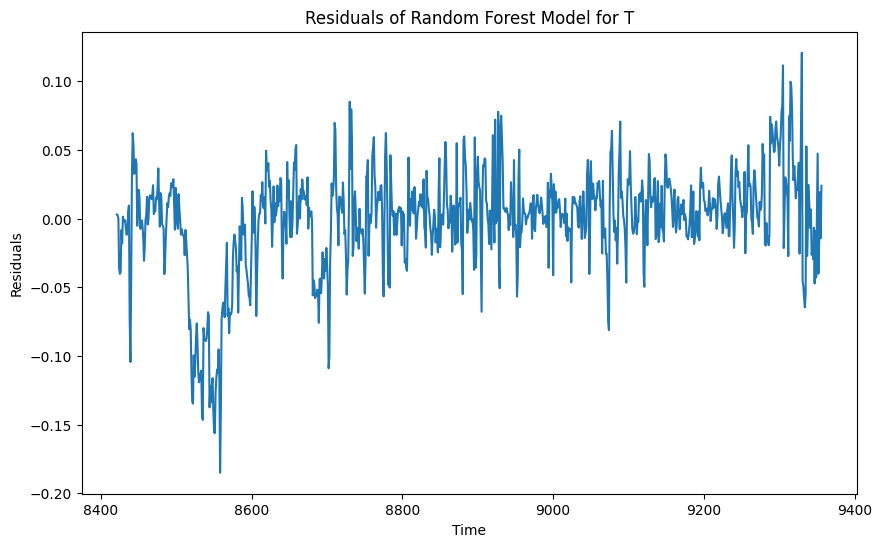

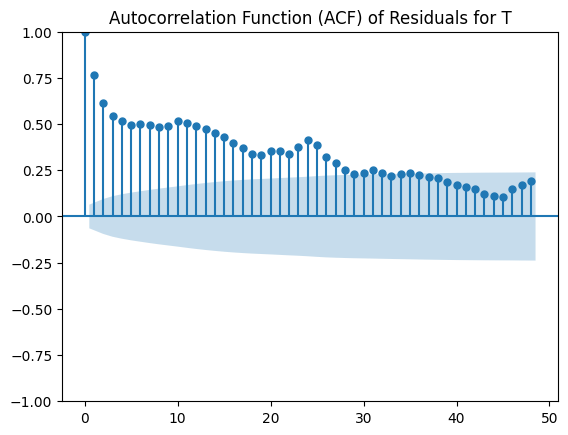

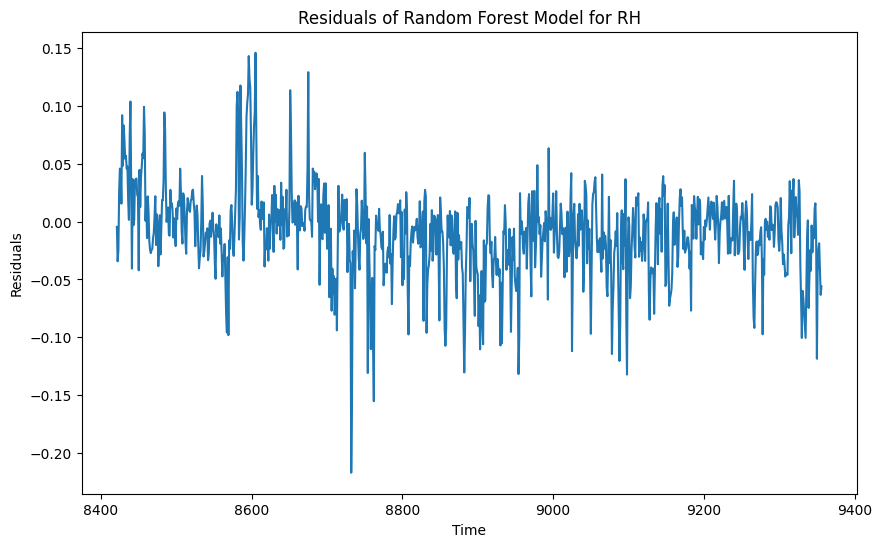

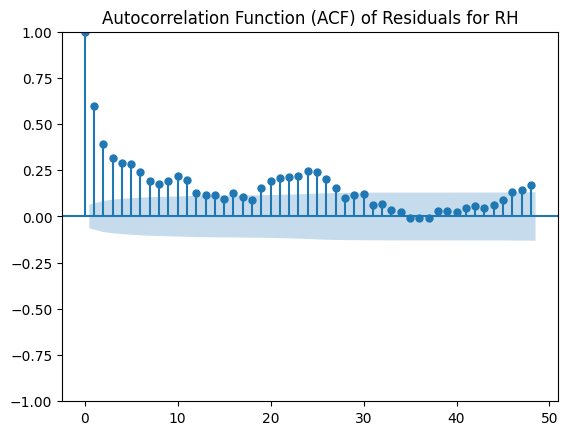

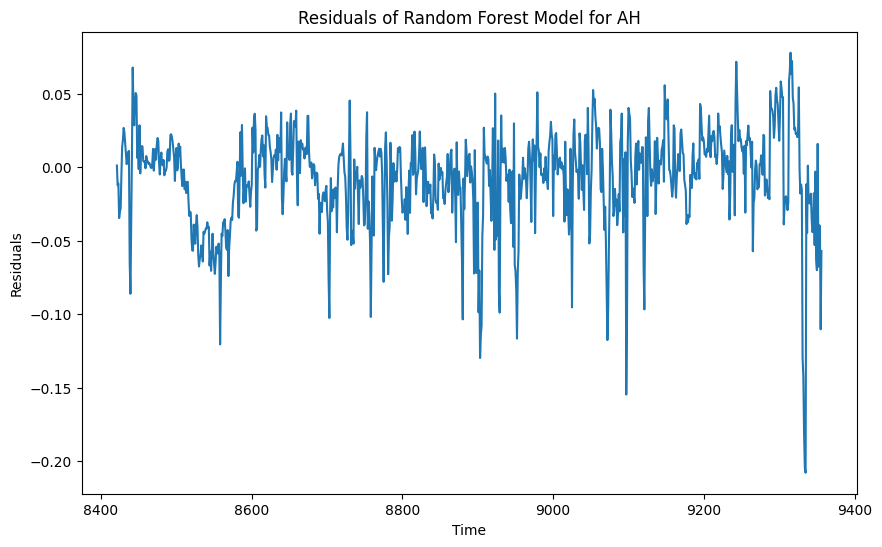

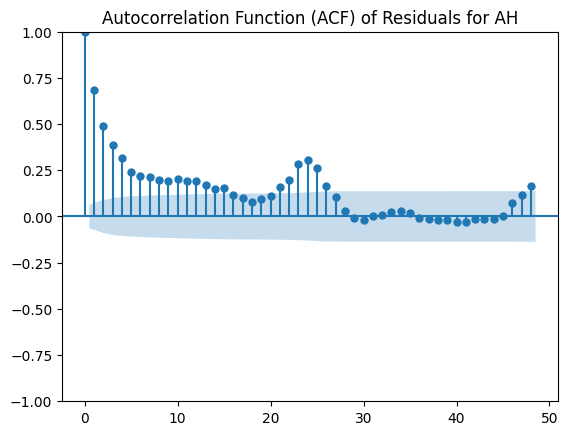

In [23]:
!pip install statsmodels
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

# Get the target variable names
target_variables = y_test.columns

# Iterate through each target variable
for target_var in target_variables:
    # Residuals for the current target variable
    residuals = y_test[target_var] - rf_predictions[:, y_test.columns.get_loc(target_var)] # Get residuals for the current target

    # Plot residuals
    plt.figure(figsize=(10, 6))
    plt.plot(residuals)
    plt.title(f'Residuals of Random Forest Model for {target_var}')
    plt.xlabel('Time')
    plt.ylabel('Residuals')
    plt.show()

    # ACF plot for residuals
    plot_acf(residuals, lags=48)  # Check for autocorrelation up to 48 hours
    plt.title(f'Autocorrelation Function (ACF) of Residuals for {target_var}')
    plt.show()

CO(GT): 0.017784804399901114
PT08.S1(CO): 0.026549595726236476
NMHC(GT): 0.012602001195887568
C6H6(GT): 0.3135866948013153
PT08.S2(NMHC): 0.03605637368325391
NOx(GT): 0.04597095636516664
PT08.S3(NOx): 0.03084764355992564
NO2(GT): 0.01677843327541931
PT08.S4(NO2): 0.02211659015833358
PT08.S5(O3): 0.026056809492073566
T: 0.21574390836971483
RH: 0.1352708862677798
AH: 0.10063530270499227


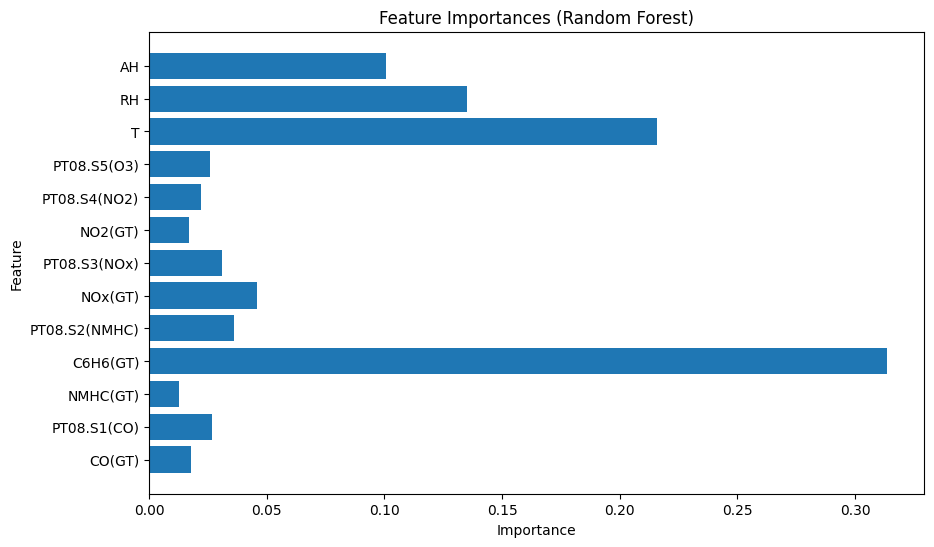

In [24]:
# Get feature importances
feature_importances = rf_model.feature_importances_

# Print feature importances
for i, feature in enumerate(X.columns):
    print(f"{feature}: {feature_importances[i]}")

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(X.columns, feature_importances)
plt.title('Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

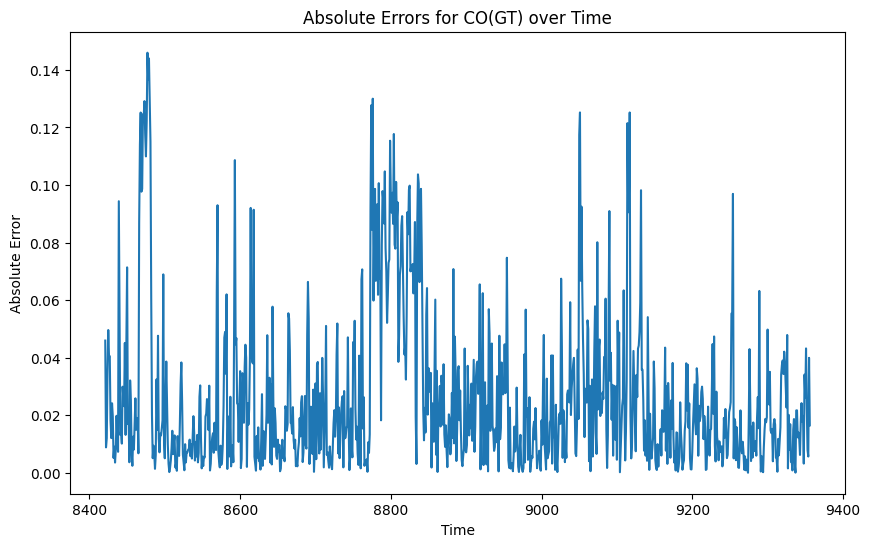

In [25]:
# Error Analysis

# Calculate absolute errors for each target variable
absolute_errors = np.abs(y_test - rf_predictions)

# Plot errors over time for CO(GT) (example)
plt.figure(figsize=(10, 6))
plt.plot(y_test.index, absolute_errors['CO(GT)'])
plt.title('Absolute Errors for CO(GT) over Time')
plt.xlabel('Time')
plt.ylabel('Absolute Error')
plt.show()

# Analyze error patterns and potential causes
# ... (Add your analysis here based on the error plot and other insights) ...

# Potential Improvements

# Feature Engineering - Lagged Variables (example)
data['CO(GT)_Lag1'] = data['CO(GT)'].shift(1)  # Create a lagged feature
data = data.dropna()  # Drop rows with NaN values due to lagging

# ... (Add more feature engineering steps as needed) ...

# Retrain the model with new features
# ... (Repeat model training and evaluation with the updated data) ...

In [ ]:
# Assuming you have predictions for the next 48 hours in a DataFrame called 'future_predictions'

# Create a submission DataFrame with the required format
submission_df = pd.DataFrame({
    'Date': pd.date_range(start=data['Datetime'].iloc[-1] + pd.Timedelta(hours=1), periods=48, freq='H'),
    'Time': pd.date_range(start=data['Datetime'].iloc[-1] + pd.Timedelta(hours=1), periods=48, freq='H').strftime('%H:%M:%S'),
    'CO(GT)': future_predictions['CO(GT)'],
    'PT08.S1(CO)': future_predictions['PT08.S1(CO)'],
    'NMHC(GT)': future_predictions['NMHC(GT)'],
    'C6H6(GT)': future_predictions['C6H6(GT)'],
    'PT08.S2(NMHC)': future_predictions['PT08.S2(NMHC)'],
    'NOx(GT)': future_predictions['NOx(GT)'],
    'PT08.S3(NOx)': future_predictions['PT08.S3(NOx)'],
    'NO2(GT)': future_predictions['NO2(GT)'],
    'PT08.S4(NO2)': future_predictions['PT08.S4(NO2)'],
    'PT08.S5(O3)': future_predictions['PT08.S5(O3)'],
    'T': future_predictions['T'],
    'RH': future_predictions['RH'],
    'AH': future_predictions['AH']
})

# Save the submission DataFrame to an Excel file
submission_df.to_excel('submission.xlsx', index=False)